# Manuscript Figures

Renders the spike manuscript figure surface from the CSVs exported by
`evaluate` and `cross_validation`.

This notebook reads **CSVs only**. It must never load `fit_collection.pkl`
(1.76 GB) — everything it needs was exported by `evaluate` for exactly that
reason.

**Figures produced**

| Fig | File |
|-----|------|
| S6  | `raw_data_summary_barcodes_backgrounds_hist` |
| S7  | `replicate_functional_score_correlation_scatter` |
| S9  | `shrinkage_analysis_trace_plots_beta` |
| S11 | `percent_shifts_under_x_lineplot` |
| S12 | `shift_corr_Delta_BA2` |
| S16 | `convergence_all_lasso_lines` |
| S17 | `global_epistasis_and_prediction_correlations` |
| 4   | `shift_by_site_heatmap_zoom` |
| 5   | `validation_titer_fold_change` |

In [1]:
import warnings

warnings.filterwarnings("ignore")

import os
import sys

sys.path.insert(0, "notebooks")

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr

# Figure 4 reproduces the legacy notebook's zoom-effect connectors, which are
# built from these axes_grid1 / transform primitives.
from matplotlib.transforms import Bbox, TransformedBbox
from mpl_toolkits.axes_grid1.inset_locator import (
    BboxConnector,
    BboxConnectorPatch,
    BboxPatch,
)

from _common import load_config
from _downstream import (
    assert_wt_agreement,
    fetch_validation_data,
    lasso_slice,
    savefig,
    set_plot_style,
)

In [2]:
config_path = "config/config.yaml"
downstream_config_path = "config/config_downstream.yaml"
output_dir = None

In [3]:
# Parameters
config_path = "config/config.yaml"
downstream_config_path = "config/config_downstream.yaml"
output_dir = "results-prod-294-naive-baseline-arm"


In [4]:
config = load_config(config_path, downstream_config_path)
spike = config["spike"]
lasso_choice = spike["lasso_choice"]
condition_titles = spike["condition_titles"]
condition_colors = spike["condition_colors"]
domain_dict = spike["domain_dict"]

fig_cfg = spike["figures"]
FORMATS = tuple(fig_cfg["formats"])
DPI = fig_cfg["dpi"]
EXCLUDED_FUSIONREG = fig_cfg["excluded_fusionreg"]
heatmap_cfg = fig_cfg["heatmap"]
validation_cfg = fig_cfg["validation"]

if output_dir is None:
    output_dir = spike.get("output_dir", "results")

FIGURES_DIR = os.path.join(output_dir, "figures")
set_plot_style()

# Conditions in manuscript order. Omicron_BA1 is the reference condition, so
# it has no shift column -- shift figures use the other two.
REFERENCE = "Omicron_BA1"
CONDITIONS = ["Delta", "Omicron_BA1", "Omicron_BA2"]
SHIFT_CONDITIONS = [c for c in CONDITIONS if c != REFERENCE]

print(f"lasso_choice = {lasso_choice:g}")
print(f"figures -> {FIGURES_DIR}")
print(f"excluded fusionreg rungs: {EXCLUDED_FUSIONREG or 'none'}")

lasso_choice = 8e-05
figures -> results-prod-294-naive-baseline-arm/figures
excluded fusionreg rungs: [0.00128]


In [5]:
def read(name):
    """Read an exported CSV from the pipeline results directory."""
    return pd.read_csv(os.path.join(output_dir, name))


func_score_df = read("training_functional_scores.csv").fillna(
    {"aa_substitutions": ""}
)
mutations_df = read("mutations_df.csv")
collection_muts = read("collection_muts.csv")
fit_sparsity = read("fit_sparsity.csv")
replicate_corr = read("library_replicate_correlation.csv")
convergence_trajectory = read("convergence_trajectory.csv")
fit_convergence = read("fit_convergence.csv")
ge_variants = read("ge_landscape_variants.csv")
ge_curve = read("ge_landscape_curve.csv")
ge_params = read("ge_params.csv")
cv_loss = read("cross_validation_loss.csv")

print(f"func_score_df          {func_score_df.shape}")
print(f"mutations_df           {mutations_df.shape}")
print(f"collection_muts        {collection_muts.shape}")
print(f"convergence_trajectory {convergence_trajectory.shape}")

func_score_df          (303007, 7)
mutations_df           (5809, 20)
collection_muts        (125150, 15)
convergence_trajectory (4028, 31)


In [6]:
def drop_excluded(df, column="fusionreg"):
    """Remove regularization rungs excluded from analysis.

    The top rung of the prod ladder is retained in the fit (removing it would
    force a full refit) but is unstable -- one replicate hits the sweep cap
    with drift_frac 0.10. Figures that sweep the ladder must not present it as
    a normal point. See ``spike.figures.excluded_fusionreg``.

    Two different treatments are correct for the two figures that sweep the
    ladder, and the config comment's "(S9, S16)" wording elides this:

    - **S9 (shrinkage) drops it, via this function.** Its three panels are the
      lambda-selection criteria, which are only meaningful for fits that
      converged, and its x-axis is categorical over the analysed ladder.
    - **S16 (convergence) plots it and MARKS it**, bypassing this function and
      iterating ``FULL_LADDER`` instead. Convergence is S16's subject; hiding
      the one fit that did not converge would assert the opposite of the truth.

    Marking S9's omitted rung on its categorical axis is a separate change
    (``rung_x`` would need a tenth slot) and is not attempted here.
    """
    if not EXCLUDED_FUSIONREG:
        return df
    return df[~df[column].isin(EXCLUDED_FUSIONREG)]


LADDER = sorted(drop_excluded(collection_muts)["fusionreg"].unique())

# The FULL ladder, excluded rungs included. Figures that claim to show "all
# rungs" iterate this and mark the excluded ones, rather than iterating LADDER
# and silently omitting them -- see spike.figures.excluded_fusionreg, which
# says such figures "mark it rather than silently showing it as a normal
# point".
FULL_LADDER = sorted(collection_muts["fusionreg"].unique())

# Ground truth for which fits actually failed, keyed by (dataset, rung). The
# instability is per-CELL, not per-rung: at 1.28e-3 rep_1 hits the sweep cap
# with drift_frac 0.10 while rep_2 converges cleanly in 109 sweeps. Greying
# rep_2's trace would substitute one dishonesty for another, so the mark is
# driven by this set rather than by fusionreg alone.
NONCONVERGED = {
    (r.dataset_name, r.fusionreg)
    for r in fit_convergence.itertuples()
    if not r.converged
}
print(f"full ladder ({len(FULL_LADDER)} rungs); "
      f"non-converged fits: {sorted(NONCONVERGED)}")
print(f"analysed ladder ({len(LADDER)} rungs): {[f'{x:g}' for x in LADDER]}")

full ladder (10 rungs); non-converged fits: [('rep_1', 0.00128)]
analysed ladder (9 rungs): ['0', '5e-06', '1e-05', '2e-05', '4e-05', '8e-05', '0.00016', '0.00032', '0.00064']


## Figure S6 — variant counts per background

Barcode (variant) count distributions per background and replicate. Reads
the post-filter training set, so counts reflect what the model actually saw.

  wrote results-prod-294-naive-baseline-arm/figures/raw_data_summary_barcodes_backgrounds_hist.pdf
  wrote results-prod-294-naive-baseline-arm/figures/raw_data_summary_barcodes_backgrounds_hist.png


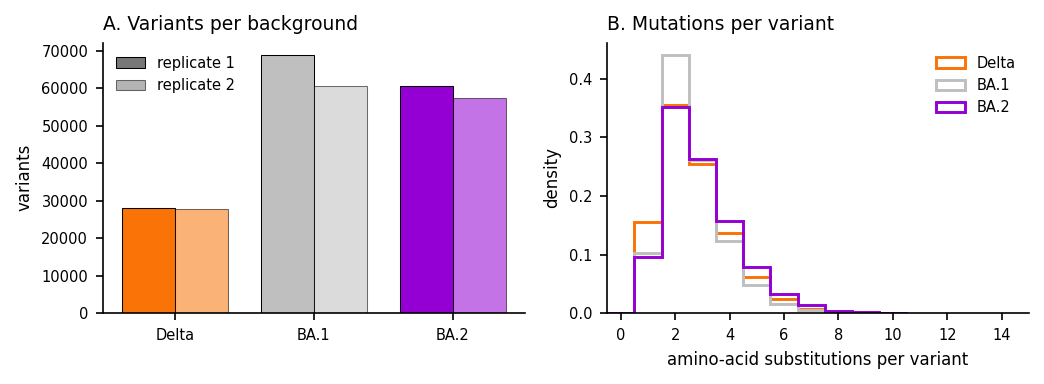

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6))

# Panel A: variants per condition/replicate.
counts = (
    func_score_df.groupby(["condition", "replicate"]).size().reset_index(name="n")
)
width = 0.38
x = np.arange(len(CONDITIONS))
replicates = sorted(counts["replicate"].unique())
for i, rep in enumerate(replicates):
    sub = counts[counts["replicate"] == rep].set_index("condition")
    heights = [sub.loc[c, "n"] for c in CONDITIONS]
    axes[0].bar(
        x + (i - 0.5) * width,
        heights,
        width,
        color=[condition_colors[c] for c in CONDITIONS],
        edgecolor="black",
        linewidth=0.5,
        alpha=1.0 if i == 0 else 0.55,
    )
axes[0].set_xticks(x)
axes[0].set_xticklabels([condition_titles[c] for c in CONDITIONS])
axes[0].set_ylabel("variants")
axes[0].set_title("A. Variants per background", loc="left")
# Bars are colored by CONDITION, so a colored legend swatch would imply the
# color encodes replicate. Use neutral grey patches keyed to the alpha
# difference, which is what actually distinguishes the pairs.
axes[0].legend(
    handles=[
        patches.Patch(
            facecolor="#777777",
            alpha=1.0 if i == 0 else 0.55,
            edgecolor="black",
            linewidth=0.5,
            label=f"replicate {rep}",
        )
        for i, rep in enumerate(replicates)
    ],
    frameon=False,
)

# Panel B: distribution of mutations per variant.
for c in CONDITIONS:
    sub = func_score_df[func_score_df["condition"] == c]
    axes[1].hist(
        sub["n_subs"],
        bins=np.arange(0, sub["n_subs"].max() + 2) - 0.5,
        histtype="step",
        linewidth=1.4,
        color=condition_colors[c],
        label=condition_titles[c],
        density=True,
    )
axes[1].set_xlabel("amino-acid substitutions per variant")
axes[1].set_ylabel("density")
axes[1].set_title("B. Mutations per variant", loc="left")
axes[1].legend(frameon=False)
axes[1].set_xlim(-0.5, 15)

fig.tight_layout()
savefig(fig, "raw_data_summary_barcodes_backgrounds_hist", FIGURES_DIR, FORMATS, DPI)
plt.show()

## Figure S7 — replicate functional-score correlation

Per-background scatter of functional scores for variants observed in both
replicate libraries, with Pearson r.

  wrote results-prod-294-naive-baseline-arm/figures/replicate_functional_score_correlation_scatter.pdf
  wrote results-prod-294-naive-baseline-arm/figures/replicate_functional_score_correlation_scatter.png


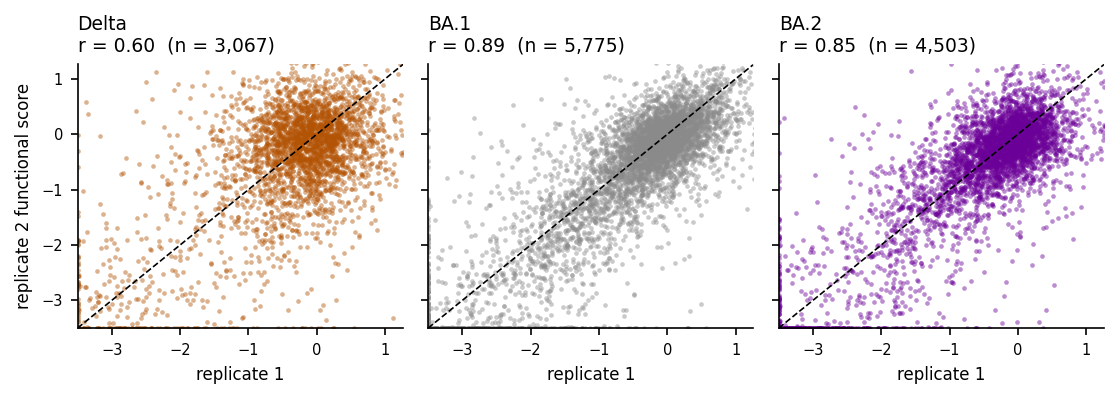

In [8]:
# BA.1's configured colour is #BFBFBF, a light grey that all but disappears on
# white at low alpha. Every condition colour is pulled toward black by the same
# factor so the three panels stay visually comparable.
def darken(hex_color, factor=0.72):
    """Blend a hex colour toward black; factor 1.0 leaves it unchanged."""
    rgb = mcolors.to_rgb(hex_color)
    return tuple(channel * factor for channel in rgb)


fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.7), sharex=True, sharey=True)

for ax, cond in zip(axes, CONDITIONS):
    sub = func_score_df[func_score_df["condition"] == cond]
    wide = sub.pivot_table(
        index="aa_substitutions", columns="replicate", values="func_score"
    ).dropna()
    reps = sorted(wide.columns)
    xv, yv = wide[reps[0]].to_numpy(), wide[reps[1]].to_numpy()
    ax.scatter(
        xv,
        yv,
        s=5,
        alpha=0.45,
        color=darken(condition_colors[cond]),
        linewidths=0,
        rasterized=True,
    )
    r = pearsonr(xv, yv)[0]
    ax.set_title(f"{condition_titles[cond]}\nr = {r:.2f}  (n = {len(wide):,})", loc="left")
    ax.set_xlabel(f"replicate {reps[0]}")
    lo = float(np.nanpercentile(np.concatenate([xv, yv]), 0.5))
    hi = float(np.nanpercentile(np.concatenate([xv, yv]), 99.5))
    ax.plot([lo, hi], [lo, hi], ls="--", lw=0.8, color="black", zorder=3)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

axes[0].set_ylabel("replicate 2 functional score")
fig.tight_layout()
savefig(
    fig,
    "replicate_functional_score_correlation_scatter",
    FIGURES_DIR,
    FORMATS,
    DPI,
)
plt.show()

## Figure S16 — convergence across the lasso ladder

The outer convergence criterion is a *between-sweep relative change* in the
objective, not a gradient norm:

$$\text{objective\_error} = \frac{|f_{k-1} - f_k|}{\max(|f_{k-1}|, |f_k|, 1)}$$

compared against `tol`. One line per (replicate, lasso weight).

This panel plots the **full** ladder, including the 1.28e-3 rung that is
excluded from analysis elsewhere. A convergence figure that dropped the only
non-converged fit would assert the opposite of the truth. Marked traces
(grey, dashed) are rungs excluded from analysis or fits that never crossed
`tol`; the single non-converged fit — `rep_1` at 1.28e-3, which hit the
500-sweep cap with `drift_frac` 0.10 — is annotated directly. Note that
`rep_2` at the same rung converged normally in 109 sweeps, so the instability
is per-fit, not a property of the rung.

  wrote results-prod-294-naive-baseline-arm/figures/convergence_all_lasso_lines.pdf


  wrote results-prod-294-naive-baseline-arm/figures/convergence_all_lasso_lines.png


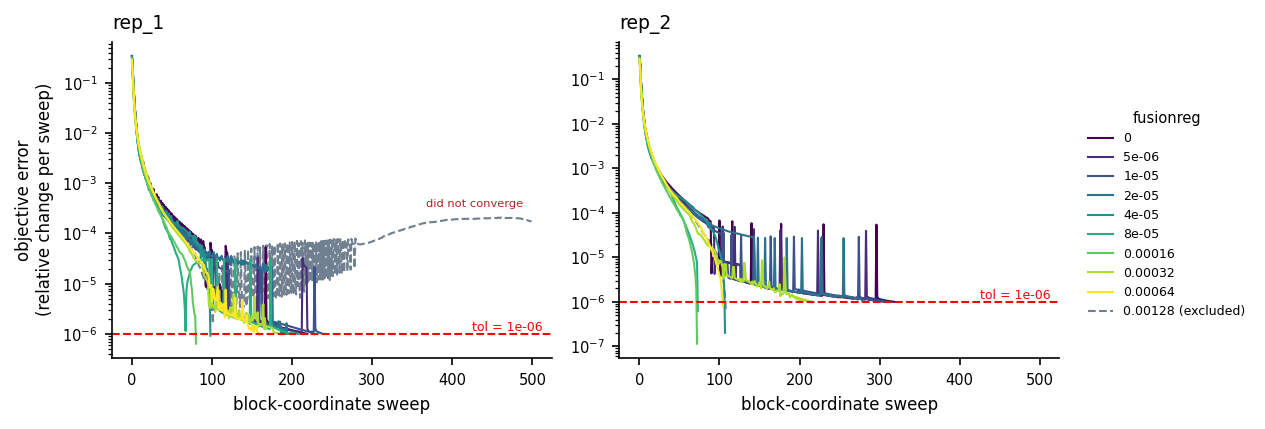

In [9]:
# S16 plots the FULL ladder, including rungs excluded from analysis, because
# its subject IS convergence: hiding the one fit that did not converge is the
# single most misleading thing this figure could do. Excluded/non-converged
# traces are drawn in grey and dashed and called out in the legend, per
# spike.figures.excluded_fusionreg ("mark it rather than silently showing it
# as a normal point").
traj = convergence_trajectory
tol = spike["fitting"]["tol"]

fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.9), sharex=True)
datasets = sorted(traj["dataset_name"].unique())
cmap = plt.get_cmap("viridis")
# Colour by position in the ANALYSED ladder so the palette is unchanged from
# the version of this figure that omitted the excluded rung; marked traces are
# drawn in grey and take no colour slot.
norm = plt.Normalize(0, max(len(LADDER) - 1, 1))

marked_any = False
for ax, ds in zip(axes, datasets):
    sub = traj[traj["dataset_name"] == ds]
    for fr in FULL_LADDER:
        s = sub[sub["fusionreg"] == fr].sort_values("iteration")
        if s.empty:
            continue
        excluded = fr in EXCLUDED_FUSIONREG
        failed = (ds, fr) in NONCONVERGED
        if excluded or failed:
            style = dict(lw=1.0, color="slategrey", ls="--", zorder=1)
            marked_any = True
        else:
            style = dict(lw=1.0, color=cmap(norm(LADDER.index(fr))), zorder=2)
        ax.semilogy(
            s["iteration"],
            s["objective_error_trajectory"].clip(lower=1e-12),
            label=f"{fr:g}",
            **style,
        )
        # Annotate the fits that never crossed tol, at the end of their trace.
        if failed:
            ax.annotate(
                "did not converge",
                xy=(s["iteration"].iloc[-1], s["objective_error_trajectory"].iloc[-1]),
                xytext=(-4, 6),
                textcoords="offset points",
                ha="right",
                va="bottom",
                fontsize=5.5,
                color="firebrick",
            )
    ax.axhline(tol, ls="--", lw=1.0, color="red")
    ax.text(
        0.98,
        tol,
        f"  tol = {tol:g}",
        transform=ax.get_yaxis_transform(),
        ha="right",
        va="bottom",
        fontsize=6,
        color="red",
    )
    ax.set_title(ds, loc="left")
    ax.set_xlabel("block-coordinate sweep")

axes[0].set_ylabel("objective error\n(relative change per sweep)")

# The legend is harvested from axes[0] only, so a rung marked in one panel but
# not the other would otherwise be mislabelled. Build the fusionreg entries
# from the analysed ladder and append ONE explicit proxy for the marked
# traces, so the legend describes both panels correctly.
handles, labels = axes[0].get_legend_handles_labels()
keep = [(h, lb) for h, lb in zip(handles, labels) if float(lb) in LADDER]
handles = [h for h, _ in keep]
labels = [lb for _, lb in keep]
if marked_any:
    handles.append(mlines.Line2D([], [], color="slategrey", ls="--", lw=1.0))
    labels.append(f"{EXCLUDED_FUSIONREG[0]:g} (excluded)")
fig.legend(
    handles,
    labels,
    title="fusionreg",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=6,
    title_fontsize=7,
)
fig.tight_layout()
savefig(fig, "convergence_all_lasso_lines", FIGURES_DIR, FORMATS, DPI)
plt.show()

## Figure S9 — shrinkage analysis

Three panels sweeping the lasso ladder: replicate correlation of parameters,
held-out loss, and shift sparsity by mutation class. Together these are the
three criteria used to choose λ.

`cross_validation_loss` values are **already per-variant averages** (the
loss uses `.mean()`); do not divide by variant count again.

  wrote results-prod-294-naive-baseline-arm/figures/shrinkage_analysis_trace_plots_beta.pdf


  wrote results-prod-294-naive-baseline-arm/figures/shrinkage_analysis_trace_plots_beta.png


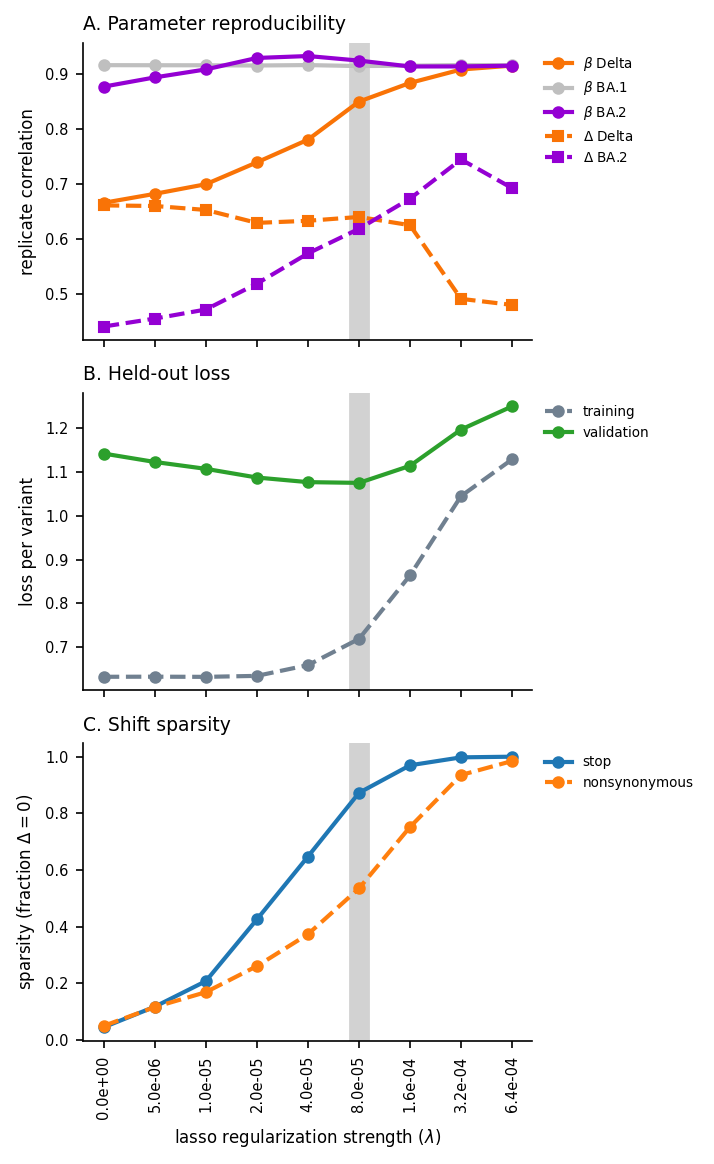

In [10]:
# The lasso ladder is plotted on a CATEGORICAL x-axis, matching the legacy
# figure (which formatted each rung as f"{lambda:.1e}" and let seaborn place
# them evenly). This is the right choice here for two reasons: the ladder
# includes lambda = 0, which no log axis can show, and the rungs are a
# hand-chosen sweep rather than samples of a continuum -- even spacing makes
# the shape of each curve legible instead of crushing eight rungs into the
# right-hand third of the panel.
LADDER_SORTED = sorted(LADDER)
RUNG_LABELS = [f"{x:.1e}" for x in LADDER_SORTED]
RUNG_POS = {x: i for i, x in enumerate(LADDER_SORTED)}


def rung_x(values):
    """Map fusionreg values onto their categorical positions."""
    return [RUNG_POS[v] for v in values]


fig, axes = plt.subplots(3, figsize=(4.8, 7.8), sharex=True)

# Panel A: replicate correlation of beta and shift parameters.
corr = drop_excluded(replicate_corr)
for param in ["beta_Delta", "beta_Omicron_BA1", "beta_Omicron_BA2"]:
    s = corr[corr["mut_param"] == param].sort_values("fusionreg")
    cond = param.replace("beta_", "")
    axes[0].plot(
        rung_x(s["fusionreg"]),
        s["correlation"],
        marker="o",
        ms=5,
        lw=2.0,
        color=condition_colors[cond],
        label=rf"$\beta$ {condition_titles[cond]}",
    )
for param in ["shift_Delta", "shift_Omicron_BA2"]:
    s = corr[corr["mut_param"] == param].sort_values("fusionreg")
    cond = param.replace("shift_", "")
    axes[0].plot(
        rung_x(s["fusionreg"]),
        s["correlation"],
        marker="s",
        ms=5,
        lw=2.0,
        ls="--",
        color=condition_colors[cond],
        label=rf"$\Delta$ {condition_titles[cond]}",
    )
axes[0].set_ylabel("replicate correlation")
axes[0].set_title("A. Parameter reproducibility", loc="left")
axes[0].legend(bbox_to_anchor=(1.0, 1.0), loc="upper left", frameon=False, fontsize=6.5)

# Panel B: cross-validation loss.
cvl = drop_excluded(cv_loss)
for split, ls, color in [
    ("training", "--", "slategrey"),
    ("validation", "-", "#2CA02C"),
]:
    s = (
        cvl[cvl["dataset"] == split]
        .groupby("fusionreg", as_index=False)["mean_loss"]
        .mean()
        .sort_values("fusionreg")
    )
    axes[1].plot(
        rung_x(s["fusionreg"]),
        s["mean_loss"],
        marker="o",
        ms=5,
        lw=2.0,
        ls=ls,
        color=color,
        label=split,
    )
axes[1].set_ylabel("loss per variant")
axes[1].set_title("B. Held-out loss", loc="left")
axes[1].legend(bbox_to_anchor=(1.0, 1.0), loc="upper left", frameon=False, fontsize=6.5)

# Panel C: shift sparsity, stop vs nonsynonymous.
sp = drop_excluded(fit_sparsity)
for mut_type, ls in [("stop", "-"), ("nonsynonymous", "--")]:
    s = (
        sp[sp["mut_type"] == mut_type]
        .groupby("fusionreg", as_index=False)["sparsity"]
        .mean()
        .sort_values("fusionreg")
    )
    axes[2].plot(
        rung_x(s["fusionreg"]),
        s["sparsity"],
        marker="o",
        ms=5,
        lw=2.0,
        ls=ls,
        label=mut_type,
    )
axes[2].set_ylabel(r"sparsity (fraction $\Delta = 0$)")
axes[2].set_title("C. Shift sparsity", loc="left")
axes[2].legend(bbox_to_anchor=(1.0, 1.0), loc="upper left", frameon=False, fontsize=6.5)

# The chosen lambda is marked as a wide translucent band, as in the legacy
# figure -- on a categorical axis it lands on a rung rather than between them.
for ax in axes:
    ax.axvline(RUNG_POS[lasso_choice], color="grey", linewidth=10, alpha=0.35, zorder=0)

axes[2].set_xticks(range(len(LADDER_SORTED)))
axes[2].set_xticklabels(RUNG_LABELS, rotation=90, ha="center")
axes[2].set_xlabel(r"lasso regularization strength ($\lambda$)")

sns.despine(fig)
fig.tight_layout()
savefig(fig, "shrinkage_analysis_trace_plots_beta", FIGURES_DIR, FORMATS, DPI)
plt.show()


## Figure S17 — global epistasis in three spaces

Three rows, one column per condition (Delta, BA.1, BA.2). Each row shows the
same fitted model in a different space, so the reader can see how the shared
sigmoid becomes a per-condition prediction and how well that prediction holds.

**Row A — fitness space.** The global-epistasis function `g(φ)` itself, a
sigmoid mapping the latent phenotype `φ` onto a bounded fitness scale. This
curve is *shared* by all three conditions — the same black line is drawn in
every panel — because `α` and the sigmoid are global parameters. The points
are each variant's measured functional score mapped onto the same scale
(`func_score / α + g(φ_wt)`), so the vertical gap between a point and the
curve is that variant's residual.

**Row B — functional-score space.** The measured functional scores against the
*per-condition* curve `α · (g(φ) − g(φ_wt))`. This is the same sigmoid, scaled
by `α` and shifted vertically so each condition's own wildtype sits at zero —
which is exactly the convention functional scores are reported in. Because
each condition has a different wildtype latent `φ_wt`, this curve differs
between columns even though the underlying `g` does not.

**Row C — prediction accuracy.** Predicted against measured functional score,
with the identity line and the per-condition Pearson `r`. Row B's curve
evaluated at each variant's own `φ` is precisely the prediction plotted here,
so row C is row B collapsed onto the model's own axis.

The dotted vertical line in rows A and B marks the condition's wildtype latent
phenotype `φ_wt`.

  wrote results-prod-294-naive-baseline-arm/figures/global_epistasis_and_prediction_correlations.pdf


  wrote results-prod-294-naive-baseline-arm/figures/global_epistasis_and_prediction_correlations.png


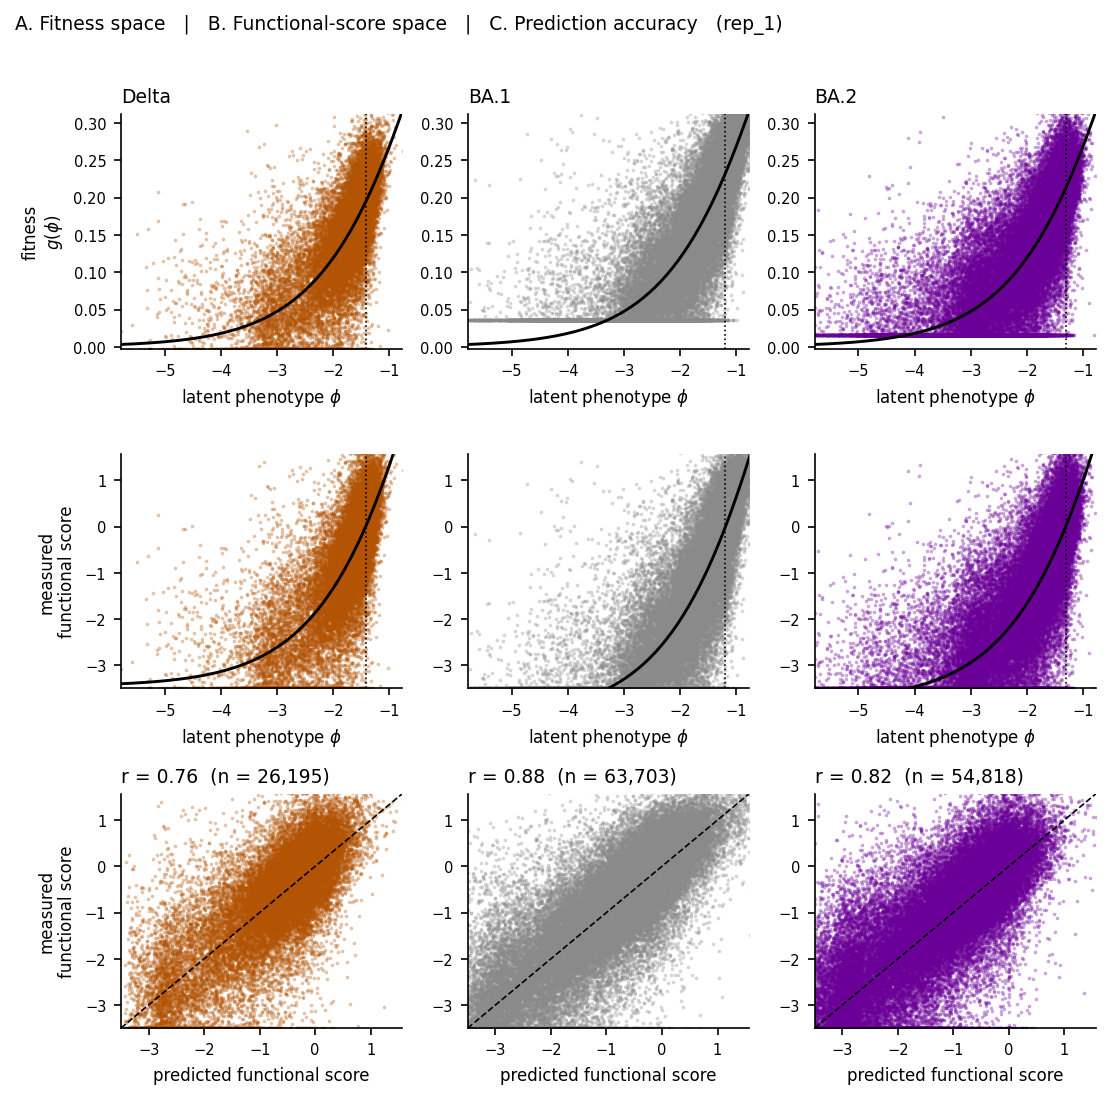

In [11]:
# The per-condition functional-score curve is exported alongside the shared
# fitness curve. It is read here rather than in the setup cell because this is
# the only figure that consumes it.
ge_curve_func_score = read("ge_landscape_curve_func_score.csv")

# Three spaces, one column per condition. Overlaying all three conditions on
# shared axes is what the legacy figure did, but with ~200k variants the
# last-drawn condition hides the other two completely -- the per-condition r
# values then describe points the reader cannot see. Faceting keeps every
# condition visible.
#
# Only the FIRST replicate is shown (rep_1). The exported frames carry both
# library replicates; they are independent fits of the same three conditions,
# so plotting both would double every panel without adding information. The
# replicate agreement itself is the subject of Figure S7.
first_ds = sorted(ge_variants["dataset_name"].unique())[0]
gv = ge_variants[ge_variants["dataset_name"] == first_ds]
gc = ge_curve[ge_curve["dataset_name"] == first_ds].sort_values("predicted_latent")
gcf = ge_curve_func_score[ge_curve_func_score["dataset_name"] == first_ds].sort_values(
    "predicted_latent"
)

# Denser, darker points than a bare scatter default: at ~200k variants a
# single-pixel marker at alpha 0.1 renders as haze. s=3 at alpha 0.35 keeps the
# dense core solid while sparse tails stay visible as individual points. BA.1's
# configured color is a light grey, so every scatter is drawn a shade darker
# than the condition color to stay legible on white. `rasterized=True` is
# essential: 200k vector points would make the PDF unopenable.
MARKER_SIZE = 3.0
MARKER_ALPHA = 0.35
SCATTER_KW = dict(s=MARKER_SIZE, alpha=MARKER_ALPHA, linewidths=0, rasterized=True)


def darken(hex_color, factor=0.72):
    """Scale an RGB hex color toward black for on-white legibility."""
    return tuple(c * factor for c in plt.matplotlib.colors.to_rgb(hex_color))


fig, axes = plt.subplots(3, len(CONDITIONS), figsize=(7.4, 7.4))

# Row 3 is a predicted-vs-measured identity plot, so both axes need one shared
# scale. Percentile clipping keeps a handful of extreme scores from
# compressing the bulk of the cloud. Row 2 shares the same y limits so the two
# functional-score rows can be read against each other.
lims = [
    float(np.nanpercentile(gv["func_score"], 0.5)),
    float(np.nanpercentile(gv["func_score"], 99.5)),
]
# Row 1 lives on the fitness scale, which is bounded by (0, 1) but occupies
# only its lower part here. Clip to the observed spread so the sigmoid's
# useful range fills the panel instead of a flat line hugging zero.
fit_lims = [
    float(np.nanpercentile(gv["measured_fitness"], 0.5)),
    float(np.nanpercentile(gv["measured_fitness"], 99.5)),
]
# The latent axis is likewise dominated by a thin tail of dead variants
# reaching phi ~ -10 while the bulk sits near -2. Clipping the tails keeps the
# informative part of the sigmoid on screen in rows 1-2.
lat_lims = [
    float(np.nanpercentile(gv["predicted_latent"], 0.25)),
    float(np.nanpercentile(gv["predicted_latent"], 99.9)),
]

for j, cond in enumerate(CONDITIONS):
    s = gv[gv["condition"] == cond]
    color = darken(condition_colors[cond])
    wt_latent = float(s["wildtype_latent"].iloc[0])

    # --- Row 1: fitness space. The sigmoid g(phi) is shared by every
    # condition, so the same black curve is drawn in all three panels; only
    # the point cloud and the wildtype marker differ between columns.
    #
    # The scatter is `measured_fitness` -- the MEASURED functional score
    # mapped onto the fitness scale, func_score / alpha + g(phi_wt) -- not
    # `predicted_fitness`. `predicted_fitness` is g(phi) evaluated at each
    # variant's own latent, so it lies exactly on the curve by construction
    # and would render as a black line hiding its own points. Plotting the
    # measurement instead makes the vertical gap to the curve the residual,
    # which is what `plot.plot_ge_landscape` defaults to as well.
    ax = axes[0, j]
    ax.scatter(s["predicted_latent"], s["measured_fitness"], color=color, **SCATTER_KW)
    ax.plot(gc["predicted_latent"], gc["ge_curve_value"], color="black", lw=1.4)
    ax.axvline(wt_latent, color="black", ls=":", lw=0.8)
    ax.set_title(condition_titles[cond], loc="left")
    ax.set_xlabel(r"latent phenotype $\phi$")
    ax.set_xlim(*lat_lims)
    ax.set_ylim(*fit_lims)
    if j == 0:
        ax.set_ylabel("fitness\n$g(\\phi)$")

    # --- Row 2: functional-score space. Measured functional scores against
    # the per-condition curve alpha * (g(phi) - g(phi_wt)) -- the same sigmoid,
    # scaled by alpha and shifted so each condition's own wildtype sits at
    # zero. That shift is what makes this curve condition-specific.
    ax = axes[1, j]
    c = gcf[gcf["condition"] == cond]
    ax.scatter(s["predicted_latent"], s["func_score"], color=color, **SCATTER_KW)
    ax.plot(c["predicted_latent"], c["func_score_curve_value"], color="black", lw=1.4)
    ax.axvline(wt_latent, color="black", ls=":", lw=0.8)
    ax.set_xlabel(r"latent phenotype $\phi$")
    ax.set_xlim(*lat_lims)
    ax.set_ylim(*lims)
    if j == 0:
        ax.set_ylabel("measured\nfunctional score")

    # --- Row 3: predicted vs measured functional score, with Pearson r.
    ax = axes[2, j]
    r = pearsonr(s["predicted_func_score"], s["func_score"])[0]
    ax.scatter(s["predicted_func_score"], s["func_score"], color=color, **SCATTER_KW)
    ax.plot(lims, lims, ls="--", lw=0.8, color="black")
    ax.set_title(f"r = {r:.2f}  (n = {len(s):,})", loc="left")
    ax.set_xlabel("predicted functional score")
    ax.set_xlim(*lims)
    ax.set_ylim(*lims)
    if j == 0:
        ax.set_ylabel("measured\nfunctional score")

fig.suptitle(
    "A. Fitness space   |   B. Functional-score space   |   "
    f"C. Prediction accuracy   ({first_ds})",
    x=0.01,
    ha="left",
    fontsize=9,
)
fig.tight_layout(rect=[0, 0, 1, 0.965])
savefig(fig, "global_epistasis_and_prediction_correlations", FIGURES_DIR, FORMATS, DPI)
plt.show()

## Figure S11 — cumulative distribution of shift magnitudes

Fraction of mutations whose absolute shift falls under a threshold, at the
chosen λ. The steep rise near zero is the lasso doing its job.

  wrote results-prod-294-naive-baseline-arm/figures/percent_shifts_under_x_lineplot.pdf
  wrote results-prod-294-naive-baseline-arm/figures/percent_shifts_under_x_lineplot.png


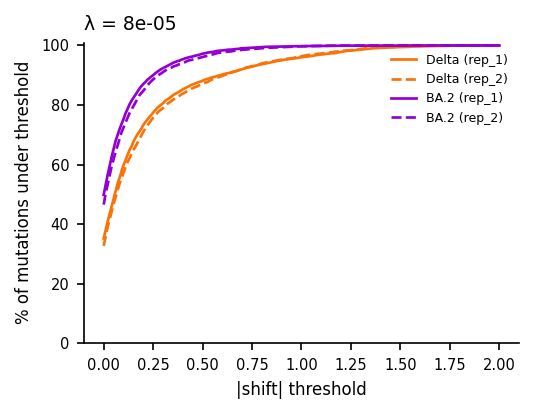

In [12]:
muts_at_lambda = lasso_slice(collection_muts, lasso_choice)

fig, ax = plt.subplots(figsize=(3.6, 2.8))
thresholds = np.linspace(0, 2.0, 200)

for cond in SHIFT_CONDITIONS:
    col = f"shift_{cond}"
    for ds, ls in zip(sorted(muts_at_lambda["dataset_name"].unique()), ["-", "--"]):
        vals = muts_at_lambda.loc[
            muts_at_lambda["dataset_name"] == ds, col
        ].abs().dropna()
        frac = [(vals <= t).mean() * 100 for t in thresholds]
        ax.plot(
            thresholds,
            frac,
            lw=1.3,
            ls=ls,
            color=condition_colors[cond],
            label=f"{condition_titles[cond]} ({ds})",
        )

ax.set_xlabel("|shift| threshold")
ax.set_ylabel("% of mutations under threshold")
ax.set_title(f"λ = {lasso_choice:g}", loc="left")
ax.legend(frameon=False, fontsize=6)
ax.set_ylim(0, 101)
fig.tight_layout()
savefig(fig, "percent_shifts_under_x_lineplot", FIGURES_DIR, FORMATS, DPI)
plt.show()

## Figure S12 — Delta vs BA.2 shift correlation

Are the condition-specific shifts shared between the two non-reference
backgrounds, or background-specific? Uses replicate-averaged shifts.

  wrote results-prod-294-naive-baseline-arm/figures/shift_corr_Delta_BA2.pdf
  wrote results-prod-294-naive-baseline-arm/figures/shift_corr_Delta_BA2.png


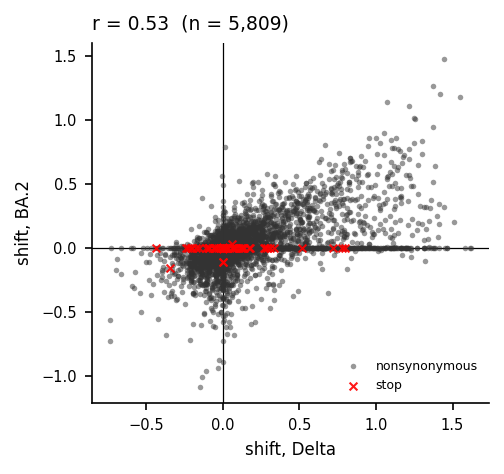

In [13]:
fig, ax = plt.subplots(figsize=(3.4, 3.2))

sub = mutations_df.dropna(subset=["avg_shift_Delta", "avg_shift_Omicron_BA2"])
nonsyn = sub[sub["sense"] == "nonsynonymous"]
stop = sub[sub["sense"] == "stop"]

ax.scatter(
    nonsyn["avg_shift_Delta"],
    nonsyn["avg_shift_Omicron_BA2"],
    s=7,
    alpha=0.5,
    color="#333333",
    linewidths=0,
    rasterized=True,
    label="nonsynonymous",
)
ax.scatter(
    stop["avg_shift_Delta"],
    stop["avg_shift_Omicron_BA2"],
    s=14,
    alpha=0.9,
    color="red",
    marker="x",
    linewidths=1.0,
    label="stop",
)

r = pearsonr(sub["avg_shift_Delta"], sub["avg_shift_Omicron_BA2"])[0]
ax.axhline(0, lw=0.6, color="black", zorder=0)
ax.axvline(0, lw=0.6, color="black", zorder=0)
ax.set_xlabel(f"shift, {condition_titles['Delta']}")
ax.set_ylabel(f"shift, {condition_titles['Omicron_BA2']}")
ax.set_title(f"r = {r:.2f}  (n = {len(sub):,})", loc="left")
ax.legend(frameon=False, fontsize=6)
fig.tight_layout()
savefig(fig, "shift_corr_Delta_BA2", FIGURES_DIR, FORMATS, DPI)
plt.show()

## Figure 5 — model prediction vs measured viral titer

The five validation mutations were introduced into pseudoviruses and their
titers measured, giving an independent test of the model's predictions.

**The x-axis is neither β nor a shift.** It is the predicted *enrichment
ratio*, `2 ** predicted_func_score_{condition}` — the legacy variable was
named `predicted_beta`, which is misleading. A reviewer asked about this
explicitly; it is answered in the response-to-reviews.

`spike_validation_data.csv` already holds titer fold-changes relative to the
unmutated background, so it is used directly rather than re-derived from
`viral_titers.csv`.

  wrote results-prod-294-naive-baseline-arm/figures/validation_titer_fold_change.pdf


  wrote results-prod-294-naive-baseline-arm/figures/validation_titer_fold_change.png


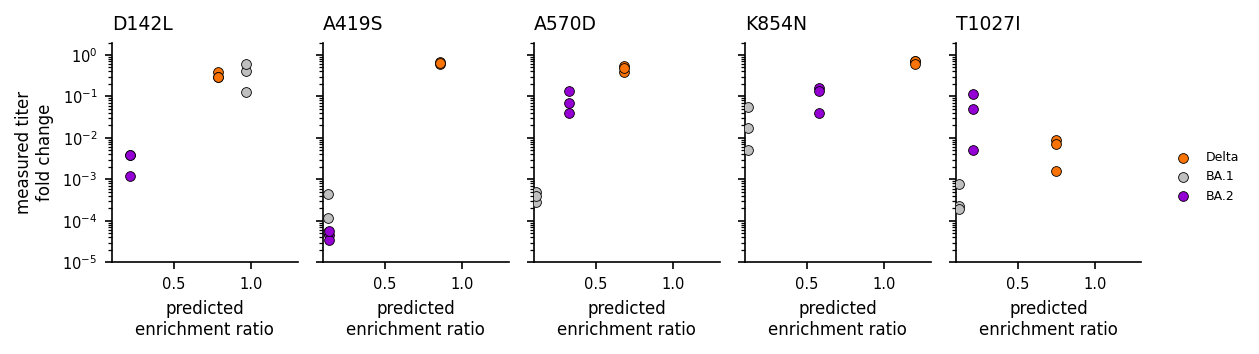

A419S predicted enrichment ratio:
   Delta: 0.854   (Delta/Delta = 1.0x)
    BA.1: 0.132   (Delta/BA.1 = 6.4x)
    BA.2: 0.137   (Delta/BA.2 = 6.2x)


In [14]:
titers, validation = fetch_validation_data(output_dir)

VALIDATION_MUTATIONS = validation_cfg["mutations"]
BACKGROUND_TO_CONDITION = validation_cfg["background_to_condition"]

# The titer file labels backgrounds "Delta"/"BA.1"/"BA.2" while the pipeline
# uses "Delta"/"Omicron_BA1"/"Omicron_BA2". Mapping is mandatory: joining on
# the raw labels silently yields an empty frame for the two Omicron rows.
measured = validation.melt(
    id_vars=["background", "replicate"],
    value_vars=VALIDATION_MUTATIONS,
    var_name="mutation",
    value_name="titer_fold_change",
)
measured["condition"] = measured["background"].map(BACKGROUND_TO_CONDITION)
unmapped = measured[measured["condition"].isna()]["background"].unique()
if len(unmapped):
    raise ValueError(
        f"Validation backgrounds {sorted(unmapped)} have no entry in "
        "spike.figures.validation.background_to_condition. Without a mapping "
        "these rows would silently drop out of the Figure 5 join."
    )

# Predicted enrichment ratio at the chosen lambda, averaged over replicates.
pred_long = []
for cond in CONDITIONS:
    col = f"predicted_func_score_{cond}"
    s = (
        muts_at_lambda[muts_at_lambda["mutation"].isin(VALIDATION_MUTATIONS)]
        .groupby("mutation", as_index=False)[col]
        .mean()
        .rename(columns={col: "predicted_func_score"})
    )
    s["condition"] = cond
    pred_long.append(s)
predicted = pd.concat(pred_long, ignore_index=True)
predicted["enrichment_ratio"] = 2 ** predicted["predicted_func_score"]

fig5 = measured.merge(predicted, on=["mutation", "condition"], how="left")

# A validation mutation can legitimately be absent: the test profile
# subsamples variants (subsample_frac), so a given mutation may never be
# observed. Drop those panels with a loud warning rather than failing --
# but on the full data this should never trigger, and an empty result still
# raises, because that means the join itself is broken (the usual cause is
# a background-name mismatch, which background_to_condition guards above).
missing = fig5[fig5["enrichment_ratio"].isna()]
if len(missing):
    absent = sorted(missing["mutation"].unique())
    print(
        f"  WARNING: no model prediction at lambda={lasso_choice:g} for "
        f"{absent}. These mutations are not in collection_muts.csv -- "
        "expected when the profile subsamples variants, unexpected on full "
        "data. Their panels are omitted."
    )
    fig5 = fig5.dropna(subset=["enrichment_ratio"])

if fig5.empty:
    raise ValueError(
        "The Figure 5 join produced no rows. Every validation mutation "
        "failed to match a model prediction, which usually means the "
        "measured/predicted key spaces disagree rather than that data is "
        f"missing. lambda={lasso_choice:g}; "
        f"validation mutations={VALIDATION_MUTATIONS}."
    )

plotted_mutations = [m for m in VALIDATION_MUTATIONS if m in set(fig5["mutation"])]
n_mut = len(plotted_mutations)
fig, axes = plt.subplots(1, n_mut, figsize=(1.55 * n_mut, 2.4), sharex=True, sharey=True)

for ax, mut in zip(np.atleast_1d(axes), plotted_mutations):
    sub = fig5[fig5["mutation"] == mut]
    for cond in CONDITIONS:
        s = sub[sub["condition"] == cond]
        ax.scatter(
            s["enrichment_ratio"],
            s["titer_fold_change"],
            s=22,
            color=condition_colors[cond],
            edgecolor="black",
            linewidth=0.4,
            label=condition_titles[cond],
            zorder=3,
        )
    ax.set_yscale("log")
    ax.set_xlim(*validation_cfg["xlim"])
    ax.set_ylim(*validation_cfg["ylim"])
    ax.set_title(mut, loc="left")
    ax.set_xlabel("predicted\nenrichment ratio")

np.atleast_1d(axes)[0].set_ylabel("measured titer\nfold change")
handles, labels = np.atleast_1d(axes)[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=6,
)
fig.tight_layout()
savefig(fig, "validation_titer_fold_change", FIGURES_DIR, FORMATS, DPI)
plt.show()

# Headline claim check (manuscript main.tex): A419S is near-neutral in Delta
# but abolishes titer in BA.1/BA.2. Reported, not asserted -- if the model's
# contrast ever collapses, the number below shows it rather than the figure
# quietly misrepresenting it.
a419s = predicted[predicted["mutation"] == "A419S"].dropna(
    subset=["enrichment_ratio"]
).set_index("condition")
if set(CONDITIONS).issubset(a419s.index):
    delta_er = a419s.loc["Delta", "enrichment_ratio"]
    print("A419S predicted enrichment ratio:")
    for cond in CONDITIONS:
        er = a419s.loc[cond, "enrichment_ratio"]
        fold = delta_er / er if er else float("inf")
        print(f"  {condition_titles[cond]:>6}: {er:.3f}   (Delta/{condition_titles[cond]} = {fold:.1f}x)")
else:
    print("A419S not present in all conditions -- headline check skipped "
          "(expected on subsampled profiles).")

## Figure 4 — shift by site, with zoom panels

Reproduces the layout of the original spike-analysis figure
(`matsengrp/SARS-CoV-2_spike_multidms@6c98b7b`, `spike-analysis.ipynb`).

Panel **A** (Delta) and panel **B** (BA.2) each pair a per-site shift scatter
with five zoomed amino-acid heatmaps, joined by zoom-effect connectors. The
domain-architecture ribbon at the top spans the primary sequence.

Marker vocabulary, from `site_map.csv`:

- black `x` — the residue is wildtype in the **reference** condition (BA.1)
- filled circle — the residue is wildtype in **this** homolog but not in BA.1
- triangle above the scatter — a site where this homolog's wildtype differs
  from BA.1's

BA.1 is the reference condition, so only Delta and BA.2 have shifts.

In [15]:
site_ranges = heatmap_cfg["site_ranges"]
AA_ORDER = heatmap_cfg["aa_order"]

# The zoom windows were chosen by eye from v0.4.0 shift values. lambda is
# unchanged at 8.0e-05, so they should still hold -- but verify rather than
# assume.
#
# Rank PER CONDITION, not on a pooled max. Delta's shifts are globally larger
# than BA.2's, so a pooled ranking buries any BA.2-specific window. zoom1 is
# exactly that case: site 142 carries D142L, one of the five experimentally
# validated mutations, with a BA.2 shift of -0.96 (rank ~6 within BA.2) but a
# Delta shift of only -0.11. A pooled metric ranks it ~131st and reads as
# "stale window" when the window is in fact validation-motivated.
#
# So: this is a report, not a gate. Windows are chosen for biological
# relevance -- shift rank is corroboration, not the selection criterion.
site_ranks = {}
for cond in SHIFT_CONDITIONS:
    s = (
        mutations_df.groupby("sites", as_index=False)[f"avg_shift_{cond}"]
        .apply(lambda x: x.abs().max())
        .rename(columns={f"avg_shift_{cond}": "abs_shift"})
        .sort_values("abs_shift", ascending=False)
        .reset_index(drop=True)
    )
    s["rank"] = s.index + 1
    site_ranks[cond] = s.set_index("sites")

n_sites = len(site_ranks[SHIFT_CONDITIONS[0]])
print(f"Zoom-window check -- strongest site per window, ranked within each "
      f"condition (of {n_sites} sites):")
for name, (lo, hi) in site_ranges.items():
    parts = []
    for cond in SHIFT_CONDITIONS:
        s = site_ranks[cond]
        win = s[(s.index >= lo) & (s.index <= hi)]
        if win.empty:
            parts.append(f"{condition_titles[cond]}: no data")
            continue
        best_site = win["abs_shift"].idxmax()
        parts.append(
            f"{condition_titles[cond]}: site {int(best_site)} "
            f"|shift|={win.loc[best_site, 'abs_shift']:.2f} "
            f"(rank {int(win.loc[best_site, 'rank'])})"
        )
    print(f"  {name} [{lo}-{hi}]  " + " | ".join(parts))

validated_sites = {
    int("".join(ch for ch in m if ch.isdigit())): m
    for m in VALIDATION_MUTATIONS
}
for name, (lo, hi) in site_ranges.items():
    hits = [m for site, m in validated_sites.items() if lo <= site <= hi]
    if hits:
        print(f"  {name} contains validated mutation(s): {', '.join(hits)}")

Zoom-window check -- strongest site per window, ranked within each condition (of 1221 sites):
  zoom1 [137-142]  Delta: site 137 |shift|=0.31 (rank 555) | BA.2: site 142 |shift|=0.96 (rank 8)
  zoom2 [416-421]  Delta: site 419 |shift|=1.47 (rank 6) | BA.2: site 417 |shift|=0.34 (rank 223)
  zoom3 [568-573]  Delta: site 568 |shift|=1.45 (rank 8) | BA.2: site 568 |shift|=1.48 (rank 1)
  zoom4 [843-856]  Delta: site 849 |shift|=1.62 (rank 1) | BA.2: site 854 |shift|=1.18 (rank 3)
  zoom5 [1019-1029]  Delta: site 1020 |shift|=1.41 (rank 14) | BA.2: site 1027 |shift|=0.78 (rank 19)
  zoom1 contains validated mutation(s): D142L
  zoom2 contains validated mutation(s): A419S
  zoom3 contains validated mutation(s): A570D
  zoom4 contains validated mutation(s): K854N
  zoom5 contains validated mutation(s): T1027I


  wrote results-prod-294-naive-baseline-arm/figures/shift_by_site_heatmap_zoom.pdf


  wrote results-prod-294-naive-baseline-arm/figures/shift_by_site_heatmap_zoom.png


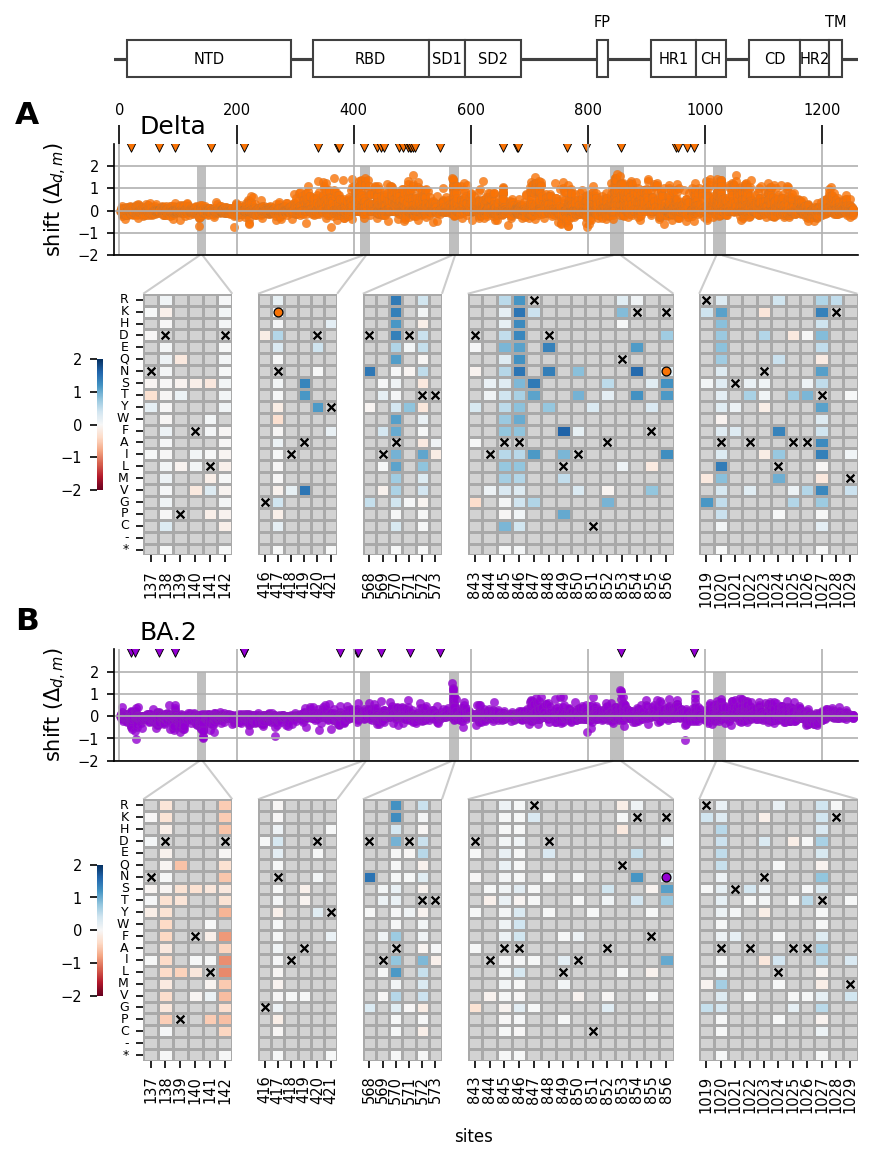

In [16]:
# Legacy Figure 4, reproduced from the original spike-analysis notebook
# (matsengrp/SARS-CoV-2_spike_multidms@6c98b7b, cell 51). The structure --
# 8-row mosaic, zoom-effect connectors, marker vocabulary, panel letters --
# is the legacy code verbatim; only the data plumbing is adapted to this
# pipeline's CSV schema.

# The legacy code refers to conditions as "BA1"/"BA2"; our CSVs use
# "Omicron_BA1"/"Omicron_BA2". Rename a working copy so the legacy body reads
# exactly as it did originally.
_rename = {"Omicron_BA1": "BA1", "Omicron_BA2": "BA2"}
mut_df = mutations_df.rename(
    columns={c: c.replace("Omicron_BA2", "BA2").replace("Omicron_BA1", "BA1")
             for c in mutations_df.columns}
)
site_map = read("site_map.csv").rename(columns=_rename).set_index("sites")

saveas = "shift_by_site_heatmap_zoom"

# heatmap ax width ratios
width_ratios = [(end - start) for key, (start, end) in site_ranges.items()]

# make the first one a little bigger for the color bar
width_ratios[0] += width_ratios[0] * 0.5

sort_order = AA_ORDER

fig = plt.figure(figsize=[6.4, 9])
axs = fig.subplot_mosaic(
    [
        ["Annotation"] * 5,
        ["Delta"] * 5,
        [f"{k}_Delta" for k in list(site_ranges.keys())],
        [f"{k}_Delta" for k in list(site_ranges.keys())],
        ["."] * 5,
        ["BA2"] * 5,
        [f"{k}_BA2" for k in list(site_ranges.keys())],
        [f"{k}_BA2" for k in list(site_ranges.keys())],
    ],
    height_ratios=[1.5, 2, 2, 2, 0.3, 2, 2, 2],
    empty_sentinel=".",
    # set the width ratios between the columns
    width_ratios=width_ratios,
    gridspec_kw={"wspace": 0.20, "hspace": 0.4},
)


# derived from
# https://matplotlib.org/stable/gallery/subplots_axes_and_figures/axes_zoom_effect.html
def connect_bbox(bbox1, bbox2, loc1a, loc2a, loc1b, loc2b,
                 prop_lines, prop_patches=None):
    if prop_patches is None:
        prop_patches = {
            **prop_lines,
            "alpha": prop_lines.get("alpha", 1) * 0.2,
            "clip_on": False,
        }

    c1 = BboxConnector(
        bbox1, bbox2, loc1=loc1a, loc2=loc2a, clip_on=False, **prop_lines)
    c2 = BboxConnector(
        bbox1, bbox2, loc1=loc1b, loc2=loc2b, clip_on=False, **prop_lines)

    bbox_patch1 = BboxPatch(bbox1, **prop_patches)
    bbox_patch2 = BboxPatch(bbox2, **prop_patches)

    p = BboxConnectorPatch(bbox1, bbox2,
                           loc1a=loc1a, loc2a=loc2a, loc1b=loc1b, loc2b=loc2b,
                           clip_on=False, **prop_patches)

    return c1, c2, bbox_patch1, bbox_patch2, p


def zoom_effect03(ax1, ax2, xmin, xmax, **kwargs):
    mybbox1 = ax1.bbox

    bbox = Bbox.from_extents(xmin, 0, xmax, 1)
    mybbox2 = TransformedBbox(bbox, ax2.get_xaxis_transform())

    prop_patches = {**kwargs, "ec": "none", "alpha": 0.2}

    c1, c2, bbox_patch1, bbox_patch2, p = connect_bbox(
        mybbox1, mybbox2,
        loc1a=2, loc2a=3, loc1b=1, loc2b=4,
        prop_lines=kwargs, prop_patches=prop_patches)

    ax2.add_patch(c1)
    ax2.add_patch(c2)
    ax2.add_patch(p)

    return c1, c2, bbox_patch1, bbox_patch2, p


#############
# sitewise
#############

cs = {"BA2": condition_colors["Omicron_BA2"], "Delta": condition_colors["Delta"]}

for (i, homolog) in enumerate(["BA2", "Delta"]):

    sns.scatterplot(
        x="sites",
        y=f"avg_shift_{homolog}",
        data=mut_df,
        # Legacy used s=15, alpha=0.7. Bumped so the points read clearly at
        # print size without saturating the dense band around zero.
        s=18,
        alpha=0.8,
        edgecolor="grey",
        linewidth=0.05,
        ax=axs[homolog],
        color=cs[homolog],
        label="",
    )

    nis = site_map.query(f"{homolog} != BA1")
    sns.scatterplot(
        x="sites",
        y=np.repeat(2.9, len(nis)),
        data=nis,
        s=30,
        ax=axs[homolog],
        marker="v",
        facecolor=cs[homolog],
        edgecolor="k",
    )

    axs[homolog].grid()
    axs[homolog].set(
        xlim=[-10, 1260],
        ylim=[-2, 3],
        yticks=[-2, -1, 0, 1, 2],
    )
    sns.despine(ax=axs[homolog])

    axs[homolog].tick_params(
        axis="x",
        bottom=False,
        labelbottom=False,
        labeltop=True if homolog == "Delta" else False,
        top=True if homolog == "Delta" else False,
        size=9,
    )
    axs[homolog].set_xlabel(None)
    axs[homolog].set_ylabel(r"shift ($\Delta_{d,m}$)", size=10)

# Legacy used the private `axs["BA2"]._shared_axes['x'].join(...)`, removed in
# modern matplotlib. The public equivalent is Axes.sharex.
axs["BA2"].sharex(axs["Delta"])

for zoom, site_range in site_ranges.items():
    (site_i, site_j) = site_range
    for (i, homolog) in enumerate(["BA2", "Delta"]):
        rect = patches.Rectangle(
            (site_i - 5, -2), site_j - site_i + 11, 4,
            edgecolor="none", facecolor="0.75", zorder=0,
        )
        axs[homolog].add_patch(rect)


#############
# Annotation
#############

for (domain, (start, end)) in domain_dict.items():
    rectangle = patches.Rectangle(
        (start, 1), end - start, 2, edgecolor="0.25", facecolor="white"
    )
    axs["Annotation"].add_patch(rectangle)
    rx, ry = rectangle.get_xy()
    cx = rx + rectangle.get_width() / 2.0
    cy = ry - 0.05 + rectangle.get_height() / 2.0
    if domain in ["FP", "TM"]:
        cy += 2
    axs["Annotation"].annotate(
        domain, (cx, cy), color="black", ha="center", va="center", fontsize=7
    )

axs["Annotation"].set(ylim=[-0.5, 4], yticks=[])
sns.despine(left=True, bottom=True, ax=axs["Annotation"])

axs["Annotation"].sharex(axs["BA2"])
axs["Annotation"].axhline(2, c="0.25", zorder=0)
axs["Annotation"].xaxis.set_tick_params(
    which="both", bottom=False, labelbottom=False, labeltop=False
)

#############
# Heatmap
#############

for (i, homolog) in enumerate(["Delta", "BA2"]):

    # Legacy used `.loc[sort_order, :]`; reindex instead, because this dataset
    # has no observed deletion ("-") mutations and .loc would KeyError. The
    # missing row then renders as the `missing_color` facecolor, as intended.
    df_shifts_wide = mut_df.pivot(
        index="muts", columns="sites", values=f"avg_shift_{homolog}"
    ).reindex(sort_order)

    for zoom, (start, end) in site_ranges.items():

        iter_ax = axs[f"{zoom}_{homolog}"]
        iter_ax.set_facecolor(heatmap_cfg["missing_color"])
        sites = [s for s in list(range(start, end + 1))
                 if s in df_shifts_wide.columns]

        sns.heatmap(
            df_shifts_wide.loc[:, sites],
            cbar=True if zoom == "zoom1" else False,
            cbar_kws={
                "shrink": 0.5,
                "location": "left",
                "anchor": (-1.5, 0.5),
                "label": None,
            },
            ax=iter_ax,
            linewidth=0.5,
            linecolor="darkgrey",
            center=0,
            cmap=heatmap_cfg["cmap"],
            vmin=heatmap_cfg["vmin"],
            vmax=heatmap_cfg["vmax"],
            xticklabels=False,
            yticklabels=False,
        )

        for i, site in enumerate(sites):
            for j, mut in enumerate(sort_order):

                is_ref_wt = mut == site_map.loc[site, "BA1"]
                if is_ref_wt:
                    iter_ax.scatter(
                        [i + 0.5], [j + 0.5], marker="x", s=14, c="black",
                        linewidths=1.1,
                    )
                is_nis = (
                    mut == site_map.loc[site, homolog]
                    and mut != site_map.loc[site, "BA1"]
                )

                if is_nis:
                    iter_ax.scatter(
                        [i + 0.5], [j + 0.5], marker="o", s=18,
                        facecolors=cs[homolog], edgecolors="black",
                        linewidths=0.6,
                    )

        if zoom != "zoom1":
            axs[f"{zoom}_{homolog}"].tick_params(
                axis="y", left=False, labelleft=False
            )
            sns.despine(left=True, bottom=True, ax=axs[f"{zoom}_{homolog}"])
        else:
            axs[f"{zoom}_{homolog}"].set_yticks(
                [s + 0.5 for s in range(len(sort_order))],
                labels=sort_order,
                va="center",
                size=6,
            )

        axs[f"{zoom}_{homolog}"].set_ylabel(None)

        if homolog != "Delta":
            axs[f"{zoom}_{homolog}"].sharex(axs[f"{zoom}_Delta"])
        axs[f"{zoom}_{homolog}"].set_xticks(
            [s + 0.5 for s in range(len(sites))],
            labels=sites,
            ha="center",
            rotation=90,
            size=7,
        )
        axs[f"{zoom}_{homolog}"].set_xlabel(None)

for zoom, (start, end) in site_ranges.items():
    for homolog in ["Delta", "BA2"]:
        zoom_effect03(axs[f"{zoom}_{homolog}"], axs[homolog], start, end, alpha=0.2)

fig.text(0.5, 0.05, "sites", ha="center")

axs["Delta"].text(
    -0.1, 1.25, "A", ha="right", va="center", size=15, weight="bold",
    transform=axs["Delta"].transAxes,
)
axs["Delta"].text(
    0.035, 1.15, condition_titles["Delta"], ha="left", va="center", size=12,
    transform=axs["Delta"].transAxes,
)

axs["BA2"].text(
    -0.1, 1.25, "B", ha="right", va="center", size=15, weight="bold",
    transform=axs["BA2"].transAxes,
)
axs["BA2"].text(
    0.035, 1.15, condition_titles["Omicron_BA2"], ha="left", va="center", size=12,
    transform=axs["BA2"].transAxes,
)

savefig(fig, saveas, FIGURES_DIR, FORMATS, DPI)
plt.show()

## Figure 3 — joint vs naive shifts, distributions and replicate agreement

Reproduces the layout of the original spike-analysis figure
(`matsengrp/SARS-CoV-2_spike_multidms@6c98b7b`, cells 84–95): a 3×3 block of
class-split distributions on top (**A**, **B**), then two rows of replicate
scatters — the joint fit (**C**, **D**) and the naive baseline (**E**, **F**).
Each scatter puts a mutation's replicate-1 value against its replicate-2
value and annotates $R^2$; the dashed royal-blue line is equivalence. Axis
limits, tick positions, bin edges, panel letters, and titles are the legacy
constants, so a reader can lay this next to the published figure.

The pairing is what makes the figure an argument. **C**/**D** are the joint
fit; **E**/**F** are the naive baseline built by `naive_baseline.ipynb` —
each condition fitted alone, shifts taken as
$\beta_d - \beta_{\text{ref}}$. Both arms are filtered at
`times_seen_threshold=1`.

**One deliberate departure from the legacy data plumbing.** The legacy
notebook built each arm with `combine_replicate_muts(how="inner")`, which
inner-joins replicates *within* an arm but leaves the two arms on different
mutation indices. Panels C–F are then a method comparison confounded with a
coverage difference. Here both arms are intersected once, up front, so all
six panels read the same mutations. Everything else — including the
hard-coded limits that leave the panels sparser than the legacy fit filled
them — is the legacy figure as published.

Two caveats belong with the numbers, and both were established by measuring
rather than assuming:

1. **The replicate $R^2$ of a difference-of-betas is confounded.** Both
   replicates subtract the same well-replicating reference beta vector, and
   that shared term manufactures correlation on its own. A permutation null
   that destroys all condition-specific signal still scores 0.70–0.82 for
   the naive arm — *higher* than what is observed. Panels E/F are therefore
   reported as the manuscript's own statistic, not as a clean measure of
   shift reproducibility. Residualizing on $\beta_{\text{ref}}$ isolates the
   real signal and gives joint a consistent ~2.1× advantage in both
   conditions.
2. **The advantage lives in the thin data.** Stratified by coverage, the
   joint arm's edge vanishes above `times_seen ≈ 10`. That is the expected
   shape of the claim — joint fitting borrows strength where a condition
   cannot stand alone — but it is a narrower claim than the pooled numbers
   suggest.

naive arm: 6/6 fits converged (tol 1e-06, max final error 9.4e-07)
naive paired 5,509 / joint 5,809 -> shared index 5,428 mutations, replicates [np.int64(1), np.int64(2)]


wildtype agreement: 5,428 mutations checked, 0 disagreeing, across a site map carrying 35 sites whose wildtype differs by background


  wrote results-prod-294-naive-baseline-arm/figures/shift_distribution_correlation_naive.pdf


  wrote results-prod-294-naive-baseline-arm/figures/shift_distribution_correlation_naive.png


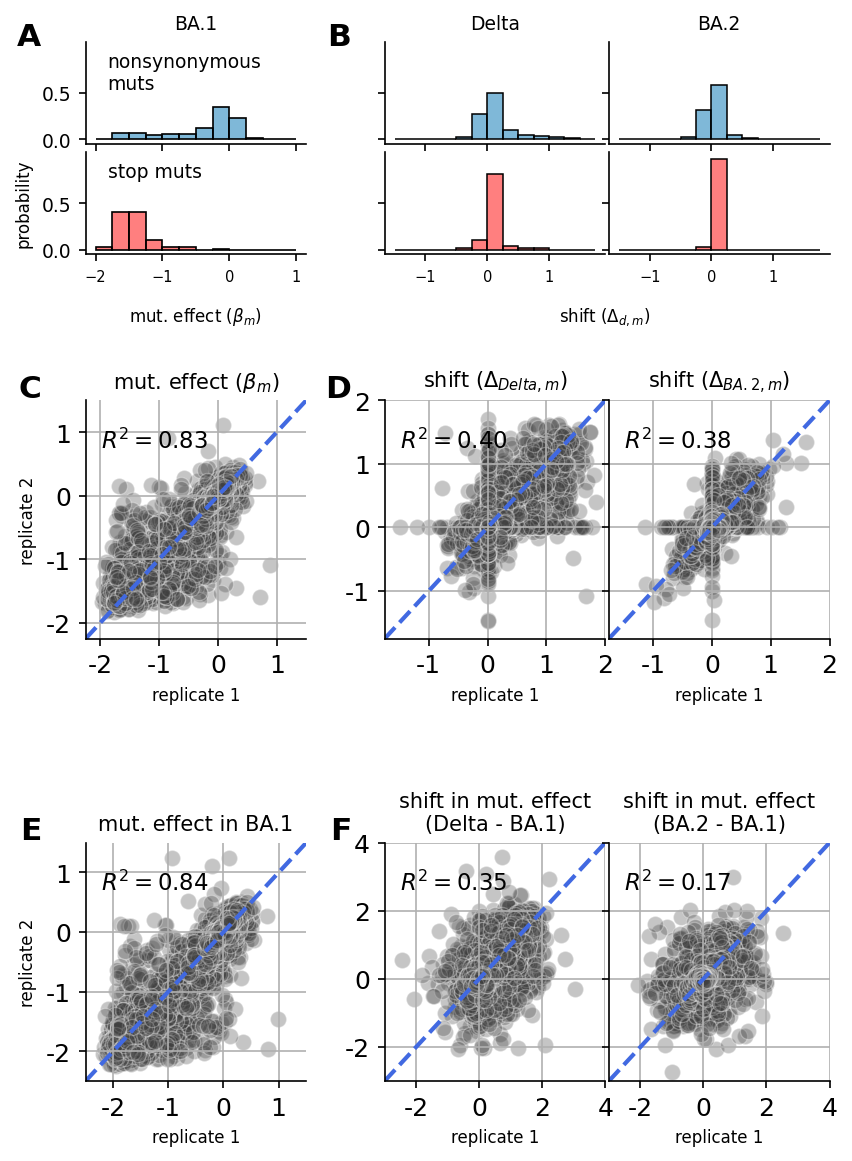

Replicate R^2 by panel:
  joint_beta                   0.833
  joint_shift_Delta            0.405
  joint_shift_Omicron_BA2      0.378
  naive_Delta_S                0.349
  naive_Omicron_BA1_beta       0.843
  naive_Omicron_BA2_S          0.169


In [17]:
# Legacy Figure 3, reproduced from the original spike-analysis notebook
# (matsengrp/SARS-CoV-2_spike_multidms@6c98b7b, cells 84-95). The structure --
# 7-row / 10-column mosaic, the 3x3 distribution block, the three-panel
# correlation rows, hard-coded limits and ticks, panel letters, titles -- is
# the legacy code verbatim; only the data plumbing is adapted to this
# pipeline's CSV schema.
#
# DEPARTURE -- the distribution block is 2 rows, not the legacy 3. The legacy
# middle row was "in-frame codon deletion muts" (`muts == '-'`). This pipeline
# deletes every deletion-bearing variant during data prep
# (prepare_data.ipynb, "Remove deletions and invalid variants" -- on main
# since #226), so no deletion mutation can reach the model and that row
# rendered as an empty labelled panel. Two classes remain because two are all
# the model has: beta is indexed by observed amino-acid substitution, and
# synonymous variants carry no substitution -- prep folds them into the
# wildtype row used for func-score subtraction, so they have no beta to plot.

naive_muts = read("naive_muts.csv")
naive_convergence = read("naive_convergence.csv")

# The equal-convergence claim is what makes the comparison fair, so it is
# reported here rather than assumed. A rule that declares an input it never
# reads is a spurious dependency edge; this is the edge earning its place.
n_converged = int(naive_convergence["converged"].sum())
print(
    f"naive arm: {n_converged}/{len(naive_convergence)} fits converged "
    f"(tol {naive_convergence['tol'].iloc[0]:g}, "
    f"max final error {naive_convergence['final_objective_error'].max():.2g})"
)

# Wide form keyed on (quantity, replicate, condition), so a panel reads
# naive_wide[("naive_shift", 1, "Delta")] the same way the joint panels read
# mutations_df["rep_1_shift_Delta"].
naive_wide = naive_muts.pivot_table(
    index="mutation",
    columns=["replicate", "condition"],
    values=["beta", "naive_shift"],
)

NAIVE_REPS = sorted(naive_muts["replicate"].unique())
if len(NAIVE_REPS) < 2:
    raise ValueError(
        f"Figure 3 compares two replicate libraries, but the naive arm "
        f"produced {len(NAIVE_REPS)}: {NAIVE_REPS}."
    )

# ONE shared index for all six scatter panels. Three separate unions hide
# here and each would quietly break the comparison:
#
#   * derive_naive_shifts intersects conditions WITHIN a replicate but not
#     ACROSS them, so naive rep 1 and rep 2 carry different mutations;
#   * pivot_table then UNIONS those two, leaving NaN columns;
#   * the joint arm's own index differs from either.
#
# The legacy notebook got this from `combine_replicate_muts(how="inner")` on
# each arm separately, which is an inner join within an arm but not between
# them. Intersecting both arms once, here, is the one deliberate departure
# from the legacy data plumbing -- see the markdown cell above.
naive_paired = naive_wide.dropna()
SHARED_INDEX = mutations_df.set_index("mutation").index.intersection(
    naive_paired.index
)
if len(SHARED_INDEX) < 2:
    raise ValueError(
        f"joint and naive arms share only {len(SHARED_INDEX)} mutations; "
        "the two key spaces disagree rather than data being missing."
    )

naive_wide = naive_paired.loc[SHARED_INDEX]
joint_muts = mutations_df.set_index("mutation").loc[SHARED_INDEX]

print(
    f"naive paired {len(naive_paired):,} / joint {len(mutations_df):,} "
    f"-> shared index {len(SHARED_INDEX):,} mutations, replicates {NAIVE_REPS}"
)

# V3: the plain intersection above is only safe because a mutation label can
# appear in every condition's index only when the wildtype letter agrees.
# Verify that against the real site map rather than trusting it.
site_map_naive = read("site_map.csv")
n_disagreeing = assert_wt_agreement(
    naive_muts[naive_muts["mutation"].isin(SHARED_INDEX)],
    site_map_naive,
    CONDITIONS,
)

# The premise is not vacuous here: the site map really does carry sites whose
# wildtype letter differs across backgrounds. None of them reach the shared
# index, which is the claim -- and it is now checked rather than assumed.
n_split_sites = int((site_map_naive[CONDITIONS].nunique(axis=1) > 1).sum())
print(
    f"wildtype agreement: {len(SHARED_INDEX):,} mutations checked, "
    f"{n_disagreeing} disagreeing, across a site map carrying "
    f"{n_split_sites} sites whose wildtype differs by background"
)

# The legacy figure names conditions "Delta"/"Omicron_BA2" in the joint block
# and reads columns "avg_shift_Delta", "1_beta", "1-Delta_S". Build those two
# frames -- one per arm -- so the plotting body below reads as it did
# originally.
DELTA, BA2 = "Delta", "Omicron_BA2"

mut_df_replicates = pd.DataFrame(index=SHARED_INDEX)
for col in ["wts", "sites", "muts"]:
    mut_df_replicates[col] = joint_muts[col]
mut_df_replicates["avg_beta"] = joint_muts[f"avg_beta_{REFERENCE}"]
mut_df_replicates["1_beta"] = joint_muts[f"rep_1_beta_{REFERENCE}"]
mut_df_replicates["2_beta"] = joint_muts[f"rep_2_beta_{REFERENCE}"]
for cond in SHIFT_CONDITIONS:
    mut_df_replicates[f"avg_shift_{cond}"] = joint_muts[f"avg_shift_{cond}"]
    mut_df_replicates[f"1_shift_{cond}"] = joint_muts[f"rep_1_shift_{cond}"]
    mut_df_replicates[f"2_shift_{cond}"] = joint_muts[f"rep_2_shift_{cond}"]

naive_mut_df = pd.DataFrame(index=SHARED_INDEX)
for rep_i, rep in enumerate(NAIVE_REPS[:2], start=1):
    naive_mut_df[f"{rep_i}-{REFERENCE}_beta"] = naive_wide[("beta", rep, REFERENCE)]
    for cond in SHIFT_CONDITIONS:
        naive_mut_df[f"{rep_i}-{cond}_S"] = naive_wide[("naive_shift", rep, cond)]


def _r2(x, y):
    """Squared Pearson correlation, the statistic the legacy figure reports.

    Returns NaN rather than raising when fewer than two pairs survive. The
    coverage strata in the block below thin out at high thresholds -- on the
    test profile the top bin empties entirely -- and a figure rule that dies
    on an empty stratum would make the whole pipeline profile-dependent.
    """
    if len(x) < 2 or len(y) < 2:
        return float("nan")
    return pearsonr(x, y)[0] ** 2


saveas = "shift_distribution_correlation_naive"
pal = sns.color_palette("colorblind")
fig = plt.figure(figsize=[6.4, 9])

# the ratio of plot to divider between
dist_sf = 3

# two rows of distributions
dist_rows = [[] for _ in range(2)]
for row, mut_type in enumerate(["m", "n"]):
    dist_rows[row].extend([f"dist_{mut_type}_beta"] * dist_sf)
    dist_rows[row].append(".")
    for param in [f"shift_{DELTA}", f"shift_{BA2}"]:
        dist_rows[row].extend([f"dist_{mut_type}_{param}"] * dist_sf)

# empty space row
empty_row = ["."] * len(dist_rows[0])

# correlation plot row
corr_row = ["corr_beta"] * dist_sf + ["."]
for param in [f"shift_{DELTA}", f"shift_{BA2}"]:
    corr_row.extend([f"corr_{param}"] * dist_sf)

# naive correlation plot row
naive_corr_row = [f"naive_corr_{REFERENCE}_beta"] * dist_sf + ["."]
for param in [f"{DELTA}_S", f"{BA2}_S"]:
    naive_corr_row.extend([f"naive_corr_{param}"] * dist_sf)

axs = fig.subplot_mosaic(
    dist_rows + [empty_row, corr_row, empty_row, naive_corr_row],
    height_ratios=[0.3, 0.3] + [0.38, 0.7, 0.55, 0.7],
    empty_sentinel=".",
    gridspec_kw={
        "wspace": 0.05,
        "hspace": 0.05,
    },
)

query_dict = {
    "m": "muts != '*' and muts != '-'",
    "n": "muts == '*'",
}

# DEPARTURE -- bins refit to this pipeline's data. The legacy ranges
# (beta to -5.25, shifts to +/-3.25) were sized for the legacy fit and leave
# ~60% of each panel empty here, with only ~5 populated 0.5-wide bins. These
# cover the observed range at half the bin width, so the distributions are
# resolved rather than blocky. Verified: no mutation falls outside them, and
# the tallest bin is 0.97, so the legacy [0, 1] probability axis still holds.
bins_dict = {
    "beta": np.arange(-2.0, 1.01, 0.25),
    f"shift_{DELTA}": np.arange(-1.5, 1.76, 0.25),
    f"shift_{BA2}": np.arange(-1.5, 1.76, 0.25),
}

#################
# DISTRIBUTIONS
#################
mut_df_replicates["sense"] = [
    "stop" if mut == "*" else "nonsynonymous" for mut in mut_df_replicates.muts
]

prefix = "avg"
# Legacy wrote `.clip(lower=-5, inplace=True)` on a column selection, which is
# a chained assignment: a no-op under modern pandas' copy-on-write. Assign the
# result so the clip the legacy figure intended actually happens.
mut_df_replicates["avg_beta"] = mut_df_replicates["avg_beta"].clip(lower=-5)

for col, param in enumerate(["beta", f"shift_{DELTA}", f"shift_{BA2}"]):
    for row, mut_type in enumerate(["m", "n"]):

        iter_ax = axs[f"dist_{mut_type}_{param}"]
        subset = mut_df_replicates.query(query_dict[mut_type])
        # Defensive: on the test profile a class can thin to nothing.
        # seaborn draws nothing for an empty frame, leaving the axes in
        # place rather than raising.
        if len(subset):
            sns.histplot(
                subset,
                x=f"{prefix}_{param}",
                ax=iter_ax,
                stat="probability",
                bins=bins_dict[param],
                label="stop",
                color="red" if mut_type == "n" else pal.as_hex()[row],
                alpha=0.5,
            )
        iter_ax.set_ylim(-0.05, 1.05)

        # remove the ylabel from all but the first column
        if col != 0:
            iter_ax.tick_params(axis="y", labelleft=False)
        iter_ax.set_yticks([0.0, 0.5], [0.0, 0.5], rotation=0, ha="right", size=9)

        if col != 0 or row != 1:
            iter_ax.set_ylabel(None)
        else:
            iter_ax.set_ylabel("probability")

        # remove the x labels from all but bottom
        if row != 1:
            iter_ax.tick_params(axis="x", labelbottom=False)
            iter_ax.set_xlabel(None)

        iter_ax.set_xlabel(None)

        sns.despine(ax=iter_ax)

axs["dist_n_beta"].set_xlabel(r"mut. effect $(\beta_{m})$")
axs["dist_n_beta"].xaxis.set_label_coords(0.5, -0.5)

axs["dist_m_beta"].text(
    0.1,
    0.9,
    "nonsynonymous\nmuts",
    ha="left",
    va="top",
    size=9,
    transform=axs["dist_m_beta"].transAxes,
)
axs["dist_n_beta"].text(
    0.1,
    0.9,
    "stop muts",
    ha="left",
    va="top",
    size=9,
    transform=axs["dist_n_beta"].transAxes,
)

axs[f"dist_n_shift_{DELTA}"].set_xlabel(r"shift ($\Delta_{d,m}$)")
axs[f"dist_n_shift_{DELTA}"].xaxis.set_label_coords(1.0, -0.5)

axs[f"dist_m_shift_{DELTA}"].set_title(condition_titles[DELTA])
axs[f"dist_m_shift_{BA2}"].set_title(condition_titles[BA2])

#################
# CORRELATIONS
#################

data = mut_df_replicates.dropna().copy()
data["1_beta"] = data["1_beta"].clip(lower=-5)
data["2_beta"] = data["2_beta"].clip(lower=-5)
r2 = {}
# plot the correlations of parameters
for col, param in enumerate(["beta", f"shift_{DELTA}", f"shift_{BA2}"]):
    iter_ax = axs[f"corr_{param}"]
    x, y = data[f"1_{param}"], data[f"2_{param}"]
    sns.scatterplot(
        data=data,
        x=f"1_{param}",
        y=f"2_{param}",
        ax=iter_ax,
        s=60,
        alpha=0.3,
        c="0.25",
    )

    # remove y labels from all but first column
    if col != 0:

        if col == 2:
            iter_ax.tick_params(axis="y", labelleft=False)
        iter_ax.set_ylabel(None)

        # DEPARTURE -- refit to data (joint shifts span -1.48 to 1.83);
        # the legacy +/-2.8 wasted ~41% of the panel. Shared across both
        # shift columns so D's two panels stay directly comparable.
        lim = [-1.75, 2.0]
        ticks = [-1, 0, 1, 2]

        iter_ax.set_ylim(lim)
        iter_ax.set_xlim(lim)
        iter_ax.set_yticks(ticks, ticks, size=12)
        iter_ax.set_xticks(ticks, ticks, rotation=0, size=12)
        # line of equivilence
        iter_ax.plot(lim, lim, linestyle="--", lw=2, c="royalblue")

    else:
        # DEPARTURE -- refit to data (joint beta spans -1.97 to 1.11);
        # the legacy [-6, 3] wasted ~66% of the panel.
        lim = [-2.25, 1.5]
        ticks = [-2, -1, 0, 1]

        iter_ax.set_ylim(lim)
        iter_ax.set_xlim(lim)
        iter_ax.set_yticks(ticks, ticks, size=12)
        iter_ax.set_xticks(ticks, ticks, rotation=0, size=12)
        # line of equivilence
        iter_ax.plot(lim, lim, linestyle="--", lw=2, c="royalblue")

        iter_ax.set_ylabel("replicate 2")

    iter_ax.set_xlabel("replicate 1")
    iter_ax.grid()

    corr = _r2(x.to_numpy(), y.to_numpy())
    r2[f"joint_{param}"] = corr
    iter_ax.annotate(
        f"$R^2 = {corr:.2f}$",
        (0.07, 0.8),
        xycoords="axes fraction",
        fontsize=11,
    )
    sns.despine(ax=iter_ax)

#################
# NAIVE CORRELATIONS
#################

data = naive_mut_df.dropna().copy()
# Legacy floor, retained. It does not bind on this fit (naive beta bottoms
# out at -2.25), so it is a guard rather than a transform -- but removing it
# would silently change behaviour on any fit where beta does run away.
data[f"1-{REFERENCE}_beta"] = data[f"1-{REFERENCE}_beta"].clip(lower=-10)
data[f"2-{REFERENCE}_beta"] = data[f"2-{REFERENCE}_beta"].clip(lower=-10)

# plot the correlations of parameters
for col, param in enumerate([f"{REFERENCE}_beta", f"{DELTA}_S", f"{BA2}_S"]):
    iter_ax = axs[f"naive_corr_{param}"]
    x, y = data[f"1-{param}"], data[f"2-{param}"]
    sns.scatterplot(
        data=data,
        x=f"1-{param}",
        y=f"2-{param}",
        ax=iter_ax,
        s=60,
        alpha=0.3,
        c="0.25",
    )

    # remove y labels from all but first column
    if col != 0:

        if col == 2:
            iter_ax.tick_params(axis="y", labelleft=False)
        iter_ax.set_ylabel(None)

        # DEPARTURE -- refit to data (naive shifts span -2.74 to 3.59);
        # the legacy [-8.2, 12.2] wasted ~69% of the panel and rendered the
        # cloud as a small off-centre blob. Shared across both F columns.
        lim = [-3.0, 4.0]
        ticks = [-2, 0, 2, 4]

        iter_ax.set_ylim(lim)
        iter_ax.set_xlim(lim)
        iter_ax.set_yticks(ticks, ticks, size=12)
        iter_ax.set_xticks(ticks, ticks, rotation=0, size=12)
        # line of equivilence
        iter_ax.plot(lim, lim, linestyle="--", lw=2, c="royalblue")

    else:
        # DEPARTURE -- refit to data (naive beta spans -2.25 to 1.25);
        # the legacy [-11, 6] wasted ~79% of the panel.
        lim = [-2.5, 1.5]
        ticks = [-2, -1, 0, 1]

        iter_ax.set_ylim(lim)
        iter_ax.set_xlim(lim)
        iter_ax.set_yticks(ticks, ticks, size=12)
        iter_ax.set_xticks(ticks, ticks, rotation=0, size=12)
        # line of equivilence
        iter_ax.plot(lim, lim, linestyle="--", lw=2, c="royalblue")

        iter_ax.set_ylabel("replicate 2")

    iter_ax.set_xlabel("replicate 1")
    iter_ax.grid()

    corr = _r2(x.to_numpy(), y.to_numpy())
    r2[f"naive_{param}"] = corr
    iter_ax.annotate(
        f"$R^2 = {corr:.2f}$",
        (0.07, 0.8),
        xycoords="axes fraction",
        fontsize=11,
    )
    sns.despine(ax=iter_ax)


# Add subpanel labels
axs["dist_m_beta"].text(
    -0.2,
    1.05,
    "A",
    ha="right",
    va="center",
    size=15,
    weight="bold",
    transform=axs["dist_m_beta"].transAxes,
)

axs[f"dist_m_shift_{DELTA}"].text(
    -0.15,
    1.05,
    "B",
    ha="right",
    va="center",
    size=15,
    weight="bold",
    transform=axs[f"dist_m_shift_{DELTA}"].transAxes,
)

axs["corr_beta"].text(
    -0.2,
    1.05,
    "C",
    ha="right",
    va="center",
    size=15,
    weight="bold",
    transform=axs["corr_beta"].transAxes,
)

axs[f"corr_shift_{DELTA}"].text(
    -0.15,
    1.05,
    "D",
    ha="right",
    va="center",
    size=15,
    weight="bold",
    transform=axs[f"corr_shift_{DELTA}"].transAxes,
)

axs[f"naive_corr_{REFERENCE}_beta"].text(
    -0.2,
    1.05,
    "E",
    ha="right",
    va="center",
    size=15,
    weight="bold",
    transform=axs[f"naive_corr_{REFERENCE}_beta"].transAxes,
)

axs[f"naive_corr_{DELTA}_S"].text(
    -0.15,
    1.05,
    "F",
    ha="right",
    va="center",
    size=15,
    weight="bold",
    transform=axs[f"naive_corr_{DELTA}_S"].transAxes,
)

# titles
axs["dist_m_beta"].set_title(condition_titles[REFERENCE])
axs["corr_beta"].set_title(r"mut. effect $(\beta_{m})$", size=10)
axs[f"corr_shift_{DELTA}"].set_title(
    rf"shift ($\Delta_{{{condition_titles[DELTA]}, m}}$)", size=10
)
axs[f"corr_shift_{BA2}"].set_title(
    rf"shift ($\Delta_{{{condition_titles[BA2]}, m}}$)", size=10
)

axs[f"naive_corr_{REFERENCE}_beta"].set_title(
    f"mut. effect in {condition_titles[REFERENCE]}", size=10
)
axs[f"naive_corr_{DELTA}_S"].set_title(
    f"shift in mut. effect\n({condition_titles[DELTA]} - "
    f"{condition_titles[REFERENCE]})",
    size=10,
)
axs[f"naive_corr_{BA2}_S"].set_title(
    f"shift in mut. effect\n({condition_titles[BA2]} - "
    f"{condition_titles[REFERENCE]})",
    size=10,
)

savefig(fig, saveas, FIGURES_DIR, FORMATS, DPI)
plt.show()

print("Replicate R^2 by panel:")
for key in sorted(r2):
    print(f"  {key:28s} {r2[key]:.3f}")

### The joint-vs-naive comparison, stated defensibly

The pooled panel-F numbers are the manuscript's statistic, and the block
below reports the two corrections that keep them from being over-read: the
permutation null for the shared-reference confound, and the coverage
stratification. Both are computed here rather than asserted, so a reader can
see the size of each effect next to the headline.


In [18]:
# The shared-beta_ref confound, measured. Permuting the condition betas
# identically in both replicates destroys every condition-specific signal
# while leaving the subtracted reference vector paired -- so whatever R^2
# survives is manufactured by the shared term alone.
rng = np.random.default_rng(0)

print("Panel F, observed vs permutation null (shared-beta_ref confound):")
for cond in SHIFT_CONDITIONS:
    b1 = naive_wide[("beta", NAIVE_REPS[0], cond)].to_numpy()
    b2 = naive_wide[("beta", NAIVE_REPS[1], cond)].to_numpy()
    r1 = naive_wide[("beta", NAIVE_REPS[0], REFERENCE)].to_numpy()
    r2_ref = naive_wide[("beta", NAIVE_REPS[1], REFERENCE)].to_numpy()
    ok = np.isfinite(b1) & np.isfinite(b2) & np.isfinite(r1) & np.isfinite(r2_ref)
    b1, b2, r1, r2_ref = b1[ok], b2[ok], r1[ok], r2_ref[ok]

    observed = _r2(b1 - r1, b2 - r2_ref)
    perm = rng.permutation(len(b1))
    null = _r2(b1[perm] - r1, b2[perm] - r2_ref)
    print(f"  {condition_titles[cond]:12s} observed {observed:.3f}   null {null:.3f}")

# Residualizing each arm's shift on the reference beta removes the shared
# term and isolates the condition-specific signal that the figure is about.
def _residualize(y, x):
    """Least-squares residual of y on x with an intercept.

    Passes short inputs through untouched; ``_r2`` reports NaN for them, and
    fitting an intercept to fewer than two points is not defined anyway.
    """
    if len(x) < 2:
        return y
    design = np.column_stack([np.ones_like(x), x])
    coef, *_ = np.linalg.lstsq(design, y, rcond=None)
    return y - design @ coef


print("\nResidualized on the reference beta (joint vs naive):")
for cond in SHIFT_CONDITIONS:
    jx = joint_muts[f"rep_1_shift_{cond}"]
    jy = joint_muts[f"rep_2_shift_{cond}"]
    jr1 = joint_muts[f"rep_1_beta_{REFERENCE}"]
    jr2 = joint_muts[f"rep_2_beta_{REFERENCE}"]
    joint = pd.concat([jx, jy, jr1, jr2], axis=1).dropna()
    joint_r2 = _r2(
        _residualize(joint.iloc[:, 0].to_numpy(), joint.iloc[:, 2].to_numpy()),
        _residualize(joint.iloc[:, 1].to_numpy(), joint.iloc[:, 3].to_numpy()),
    )

    nx = naive_wide[("naive_shift", NAIVE_REPS[0], cond)]
    ny = naive_wide[("naive_shift", NAIVE_REPS[1], cond)]
    nr1 = naive_wide[("beta", NAIVE_REPS[0], REFERENCE)]
    nr2 = naive_wide[("beta", NAIVE_REPS[1], REFERENCE)]
    naive = pd.concat([nx, ny, nr1, nr2], axis=1).dropna()
    naive_r2 = _r2(
        _residualize(naive.iloc[:, 0].to_numpy(), naive.iloc[:, 2].to_numpy()),
        _residualize(naive.iloc[:, 1].to_numpy(), naive.iloc[:, 3].to_numpy()),
    )
    ratio = joint_r2 / naive_r2 if naive_r2 else float("nan")
    print(
        f"  {condition_titles[cond]:12s} joint {joint_r2:.3f}   "
        f"naive {naive_r2:.3f}   ratio {ratio:.2f}x"
    )

# Where the advantage lives. min times_seen across both replicates and both
# conditions, so a mutation is only counted at a threshold when every fit
# that contributes to its shift saw it that often.
# min times_seen across both replicates AND all conditions. pivot_table's
# min skips NaN, so a mutation missing from one replicate would take its min
# over three columns instead of six and land in a stratum it did not earn --
# restricting to SHARED_INDEX (where all six are present) removes that.
ts = (
    naive_muts.pivot_table(
        index="mutation", columns=["replicate", "condition"], values="times_seen"
    )
    .loc[SHARED_INDEX]
    .min(axis=1)
)

print("\nCoverage stratification (shared index, joint vs naive):")
for threshold in [1, 3, 5, 10, 20]:
    keep = ts.index[ts >= threshold]
    # Thresholds that keep fewer than two mutations carry no correlation to
    # report. Skipping them keeps the block meaningful on the small test
    # profile as well as on prod.
    if len(keep) < 2:
        print(f"  ts>={threshold:<3d} skipped (n = {len(keep)})")
        continue
    row = [f"  ts>={threshold:<3d}"]
    for cond in SHIFT_CONDITIONS:
        j = joint_muts.loc[
            joint_muts.index.intersection(keep),
            [f"rep_1_shift_{cond}", f"rep_2_shift_{cond}"],
        ].dropna()
        n = naive_wide.loc[
            naive_wide.index.intersection(keep),
            [("naive_shift", NAIVE_REPS[0], cond), ("naive_shift", NAIVE_REPS[1], cond)],
        ].dropna()
        jr = _r2(j.iloc[:, 0].to_numpy(), j.iloc[:, 1].to_numpy())
        nr = _r2(n.iloc[:, 0].to_numpy(), n.iloc[:, 1].to_numpy())
        if not np.isfinite(jr) or not np.isfinite(nr) or nr == 0:
            row.append(f"{condition_titles[cond]}: n/a")
        else:
            row.append(
                f"{condition_titles[cond]}: joint {jr:.3f} naive {nr:.3f} "
                f"({jr / nr:.2f}x)"
            )
    print("  ".join(row) + f"   n = {len(keep):,}")


Panel F, observed vs permutation null (shared-beta_ref confound):
  Delta        observed 0.349   null 0.697
  BA.2         observed 0.169   null 0.811

Residualized on the reference beta (joint vs naive):


  Delta        joint 0.341   naive 0.155   ratio 2.20x
  BA.2         joint 0.391   naive 0.186   ratio 2.10x

Coverage stratification (shared index, joint vs naive):
  ts>=1    Delta: joint 0.405 naive 0.349 (1.16x)  BA.2: joint 0.378 naive 0.169 (2.23x)   n = 5,428
  ts>=3    Delta: joint 0.529 naive 0.559 (0.95x)  BA.2: joint 0.478 naive 0.378 (1.27x)   n = 4,058
  ts>=5    Delta: joint 0.641 naive 0.673 (0.95x)  BA.2: joint 0.564 naive 0.502 (1.12x)   n = 3,059
  ts>=10   Delta: joint 0.752 naive 0.793 (0.95x)  BA.2: joint 0.684 naive 0.673 (1.02x)   n = 1,736
  ts>=20   Delta: joint 0.843 naive 0.848 (0.99x)  BA.2: joint 0.800 naive 0.801 (1.00x)   n = 642
